# Analisi copy number Wakhan per gene

Parsing dei VCF di segmenti CNA prodotti da Wakhan e controllo dello stato del copy number
per una lista di geni (default: pannello GBM in `wakhan_utils.DEFAULT_GENE_BED`).

In [1]:
from wakhan_utils import (
    DEFAULT_GENE_BED,
    annotate_genes_cn,
    annotate_genes_cn_multi,
    plot_gene_cn_heatmap,
    load_gene_regions,
)

## Gene list (BED)

Percorso del BED dei geni da controllare (default: pannello GBM in `wakhan_utils.DEFAULT_GENE_BED`).
Cambia `gene_bed` qui sotto per usare un pannello diverso in tutto il notebook.

In [2]:
gene_bed = DEFAULT_GENE_BED  # cambia qui il path per usare un BED custom (chr, start, end, gene)

gene_bed = "/CTGlab/db/biorad_centromeric_copy-number-reference_assays_2026.genecode.v48.bed"

load_gene_regions(gene_bed)

,chr,start,end,gene
0,chr1,119368778,119394130,HAO2
1,chr1,119911552,120100779,NOTCH2
2,chr1,145719470,145739288,CD160
3,chr10,37125597,37232567,ANKRD30A
4,chr11,47572196,47578976,KBTBD4
5,chr11,47617314,47642607,MTCH2
6,chr12,33374237,33439819,SYT10
7,chr12,39293227,39443390,KIF21A
8,chr12,43758943,43798307,IRAK4
9,chr13,19958676,20091829,ZMYM2


## Singolo campione

In [ ]:
vcf_path = (
    "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
    "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_integers.vcf"
)

ann = annotate_genes_cn(vcf_path, gene_bed=gene_bed, output_path="single_sample_cna.tsv")
ann[["gene", "chr", "start", "end", "seg_type", "cna", "alt", "tcn", "cn1", "cn2", "overlap_bp"]]

## Confronto tra più soluzioni/campioni

Esempio: confronto tra due soluzioni Wakhan (diverse stime di purezza/ploidia) per lo stesso campione.

In [ ]:
vcf_paths = {
    "solution_1.integers": (
        "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
        "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_integers.vcf"
    ),
    "solution_1.subclonals": (
        "/CTGlab/projects/GBM/seqperglio/lumos/wakhan/GSC11/wakhan_cna/"
        "solution_1/vcf_output/Sample_3.44_0.87_0.91_wakhan_cna_subclonals.vcf"
    ),
}

df = annotate_genes_cn_multi(vcf_paths, gene_bed=gene_bed, output_path="multi_sample_cna.tsv")
df[["sample", "gene", "seg_type", "cna", "tcn", "cn1", "cn2"]]

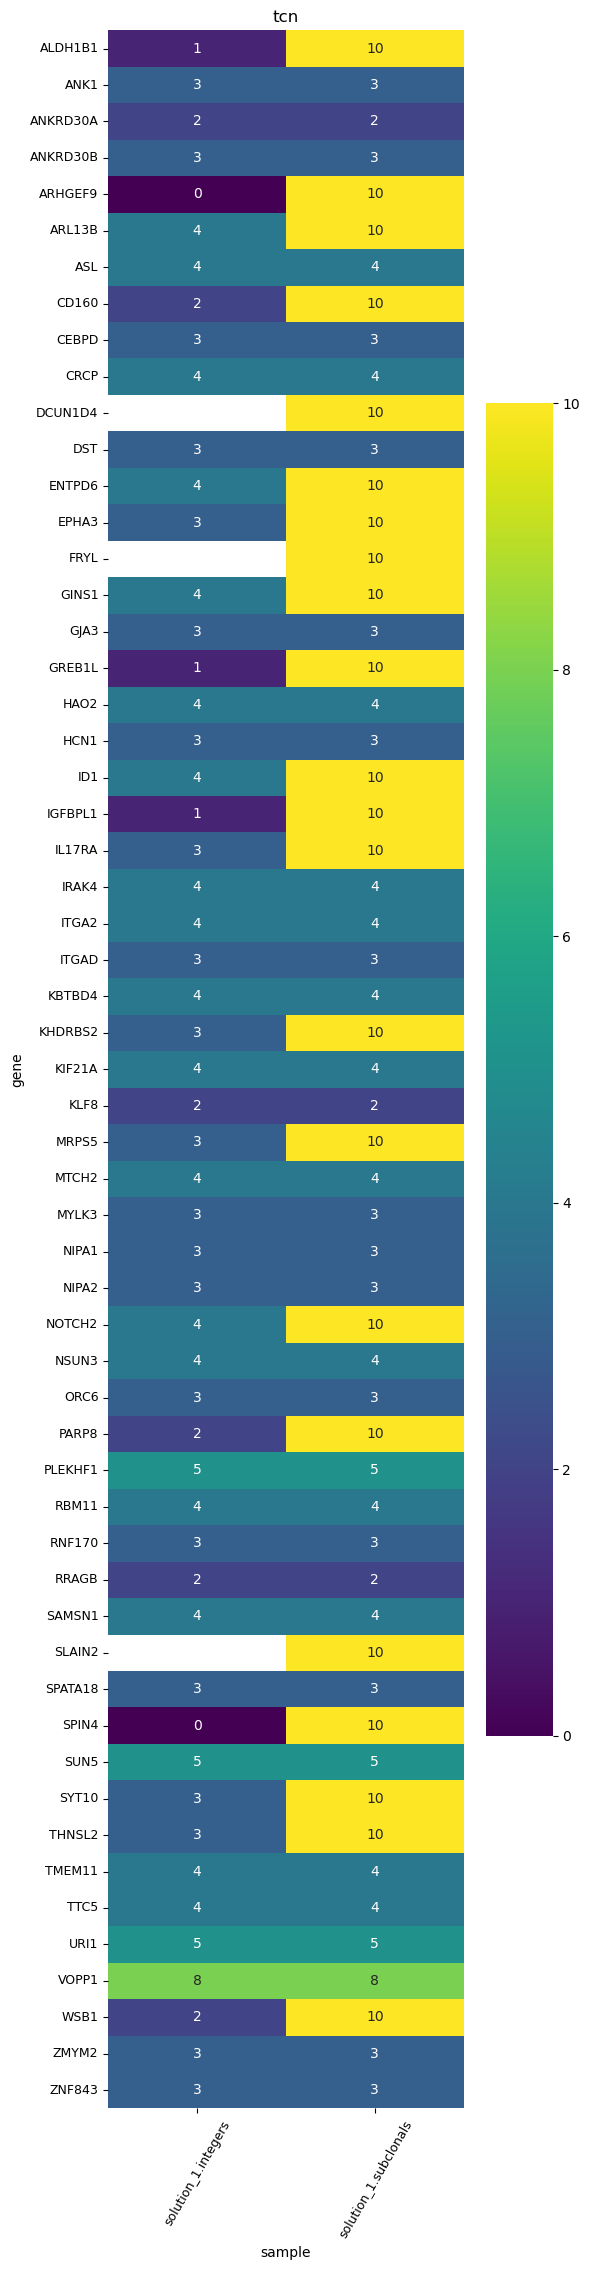

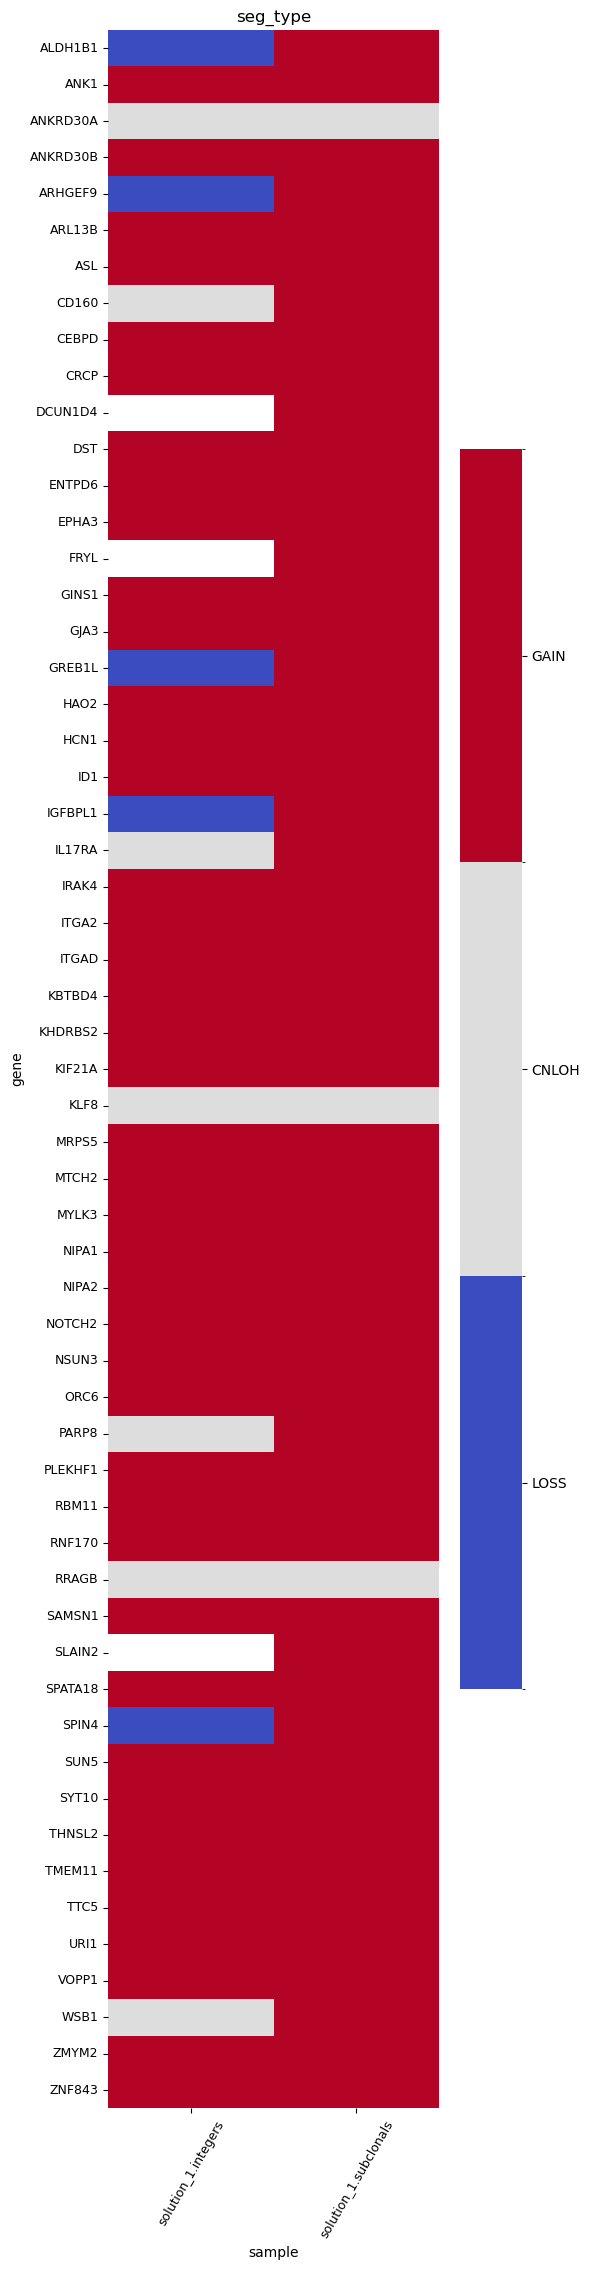

In [5]:
plot_gene_cn_heatmap(df, value="tcn")
plot_gene_cn_heatmap(df, value="seg_type")